# Econ 390 - Lecture 17: APIs using Requests Package
Today we will be looking at a more "manual" method of using APIs in Python using the `requests` package. This package is mentioned in [6.3 of McKinney](https://wesmckinney.com/book/accessing-data#io_web_apis) and in [Turrell](https://aeturrell.github.io/coding-for-economists/data-extraction.html#obtaining-data-using-apis).

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import io

## OECD API

The [OECD website](https://www.oecd.org/en/data/insights/data-explainers/2024/09/api.html) goes through their API! You'll also find a link to a PDF with more details on how to use the API.

In [3]:
# Define API query URL (CSV with labels format)
url = "https://sdmx.oecd.org/public/rest/data/OECD.GOV.GIP,DSD_GOV_INT@DF_GOV_TDG_2025,1.1/A..TRUST_NG....HMH.?startPeriod=2021&endPeriod=2021&dimensionAtObservation=AllDimensions&format=csvfilewithlabels"
# Fetch data
response = requests.get(url)

# Load into pandas DataFrame
df = pd.read_csv(StringIO(response.text))

# Display first few rows
print(df.head())

  STRUCTURE                                   STRUCTURE_ID  \
0  DATAFLOW  OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1)   
1  DATAFLOW  OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1)   
2  DATAFLOW  OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1)   
3  DATAFLOW  OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1)   
4  DATAFLOW  OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1)   

                                      STRUCTURE_NAME ACTION FREQ  \
0  Trust, security and dignity - government at a ...      I    A   
1  Trust, security and dignity - government at a ...      I    A   
2  Trust, security and dignity - government at a ...      I    A   
3  Trust, security and dignity - government at a ...      I    A   
4  Trust, security and dignity - government at a ...      I    A   

  Frequency of observation REF_AREA Reference area   MEASURE  \
0                   Annual      ISL        Iceland  TRUST_NG   
1                   Annual      KOR          Korea  TRUST_NG   
2                   Annual

In [4]:
# Type?
type(response)

requests.models.Response

In [5]:
# Status Code
response.status_code

200

In [6]:
# What does it look like?
print(type(response.text))
response.text

<class 'str'>


'STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,SECTOR,Institutional sector,EDITION,Edition,SCALE,Scale,CATEGORY,Category,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period\r\nDATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a glance indicators, 2025 edition",I,A,Annual,ISL,Iceland,TRUST_NG,Trust in national government,PT_RESP,Percentage of respondents,_Z,Not applicable,2025,2025,HMH,High and moderately high,TDG,"Trust, security and dignity",2021,,50.4,,A,Normal value,0,Units,_Z,Not applicable,,\r\nDATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a glance indicators, 2025 edition",I,A,Annual,KOR,Korea,TRUST_NG,Trust in national government,PT_RESP,Percentage of respondents,_Z,Not applicable,20

In [7]:
# Look through the DF
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period
0,DATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a ...",I,A,Annual,ISL,Iceland,TRUST_NG,Trust in national government,...,50.4,NaN,A,Normal value,0,Units,_Z,Not applicable,NaN,NaN
1,DATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a ...",I,A,Annual,KOR,Korea,TRUST_NG,Trust in national government,...,48.8,NaN,A,Normal value,0,Units,_Z,Not applicable,NaN,NaN
2,DATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a ...",I,A,Annual,COL,Colombia,TRUST_NG,Trust in national government,...,20.5,NaN,A,Normal value,0,Units,_Z,Not applicable,NaN,NaN
3,DATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a ...",I,A,Annual,DNK,Denmark,TRUST_NG,Trust in national government,...,48.8,NaN,A,Normal value,0,Units,_Z,Not applicable,NaN,NaN
4,DATAFLOW,OECD.GOV.GIP:DSD_GOV_INT@DF_GOV_TDG_2025(1.1),"Trust, security and dignity - government at a ...",I,A,Annual,EST,Estonia,TRUST_NG,Trust in national government,...,46.5,NaN,A,Normal value,0,Units,_Z,Not applicable,NaN,NaN


In [9]:
# Subset just what we need
df = df[["OBS_VALUE","REF_AREA"]]
df.index = df["REF_AREA"]
df = df.drop(index="OECD_REP")

,OBS_VALUE,REF_AREA
REF_AREA,,
ISL,50.4,ISL
KOR,48.8,KOR
COL,20.5,COL
DNK,48.8,DNK
EST,46.5,EST
JPN,24.0,JPN
FIN,61.5,FIN
LVA,24.5,LVA
LUX,55.9,LUX


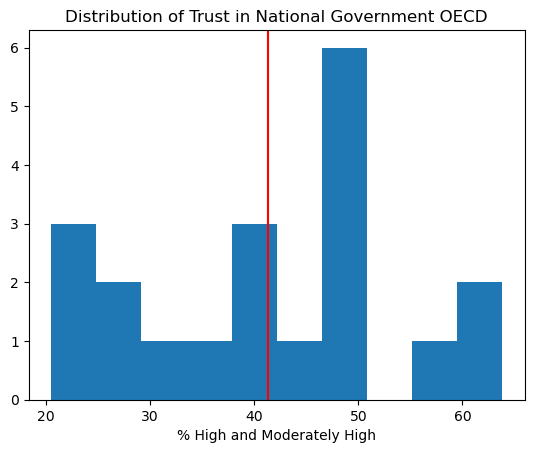

In [11]:
# Create Histogram
avg_trust = df["OBS_VALUE"].mean()
fig, ax = plt.subplots()
ax.hist(df["OBS_VALUE"])
ax.set(xlabel="% High and Moderately High",
       title="Distribution of Trust in National Government OECD")
ax.axvline(x=avg_trust,color="red")
plt.show()

## Practice: OECD API
1. Use the [OECD Data Explorer](https://data-explorer.oecd.org/) to find a dataset you'd be interested in downloading.
2. Get the API URL.
3. Display the first five rows. Does this immediately work if you just copy the URL from the API? *Hint: Make sure that you specify the format*

In [12]:
url_practice = "https://sdmx.oecd.org/public/rest/data/OECD.EDU.IMEP,DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR_EA,1.0/AUS+AUT+BEL+CAN+CHL+COL+CRI+CZE+DNK+EST+FIN+FRA+DEU+GRC+HUN+ISL+IRL+ISR+ITA+JPN+KOR+LVA+LTU+LUX+MEX+NLD+NZL+NOR+POL+PRT+SVK+SVN+ESP+SWE+CHE+TUR+GBR+USA+OECD+ARG+BRA+BGR+HRV+IND+IDN+PER+ROU+ZAF._T.Y25T64.ISCED11A_0T2+ISCED11A_3_4+ISCED11A_5T8..........OBS...A?startPeriod=2020&endPeriod=2024&lastNObservations=1&dimensionAtObservation=AllDimensions&format=csvfilewithlabels"
response_practice = requests.get(url_practice)
# Load into pandas DataFrame
df_practice = pd.read_csv(StringIO(response_practice.text))
# Display first few rows
print(df_practice.head())

  STRUCTURE                                       STRUCTURE_ID  \
0  DATAFLOW  OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...   
1  DATAFLOW  OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...   
2  DATAFLOW  OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...   
3  DATAFLOW  OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...   
4  DATAFLOW  OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_NEAC_DISTR...   

                                      STRUCTURE_NAME ACTION REF_AREA  \
0  Adults' educational attainment distribution, b...      I      PER   
1  Adults' educational attainment distribution, b...      I      LUX   
2  Adults' educational attainment distribution, b...      I      SVN   
3  Adults' educational attainment distribution, b...      I      TUR   
4  Adults' educational attainment distribution, b...      I      LVA   

  Reference area SEX    Sex     AGE                  Age  ...  OBS_VALUE  \
0           Peru  _T  Total  Y25T64  From 25 to 64 years  ...  39.276722   
1     Luxembourg  

## Census API
We'll be focusing on the [International Trade API](https://www.census.gov/data/developers/data-sets/international-trade.html) which has a pdf guide [here](https://www.census.gov/foreign-trade/reference/guides/Guide_to_International_Trade_Datasets.pdf).

In [14]:
# Base URL
base_url = "https://api.census.gov/data/timeseries/intltrade/exports/hs"

In [15]:
# Systematic components
variables = "ALL_VAL_MO" # get the variables of interes: total value
level = "HS10"           # 10-digit HS level
commodity = "2710121510" # Gasoline
country = "1220"         # Canada
dates = "from+2016-01"   # Data from 2016 through now

In [16]:
# Formulate full URL
full_url = (base_url
            + "?get=" + variables
            + "&COMM_LVL=" + level
            + "&E_COMMODITY=" + commodity
            + "&CTY_CODE=" + country
            + "&time=" + dates)

In [20]:
# Submit Query
response = requests.get(full_url)
response
full_url

'https://api.census.gov/data/timeseries/intltrade/exports/hs?get=ALL_VAL_MO&COMM_LVL=HS10&E_COMMODITY=2710121510&CTY_CODE=1220&time=from+2016-01'

In [18]:
# Content of the request
response.content

b'[["ALL_VAL_MO","COMM_LVL","E_COMMODITY","CTY_CODE","time"],\n["155905","HS10","2710121510","1220","2016-01"],\n["260801","HS10","2710121510","1220","2016-02"],\n["241362","HS10","2710121510","1220","2016-03"],\n["461102","HS10","2710121510","1220","2016-04"],\n["442085","HS10","2710121510","1220","2016-05"],\n["449950","HS10","2710121510","1220","2016-06"],\n["398612","HS10","2710121510","1220","2016-07"],\n["214201","HS10","2710121510","1220","2016-08"],\n["260553","HS10","2710121510","1220","2016-09"],\n["94817","HS10","2710121510","1220","2016-10"],\n["93819","HS10","2710121510","1220","2016-11"],\n["119305","HS10","2710121510","1220","2016-12"],\n["118137","HS10","2710121510","1220","2017-01"],\n["54086","HS10","2710121510","1220","2017-02"],\n["116552","HS10","2710121510","1220","2017-03"],\n["318672","HS10","2710121510","1220","2017-04"],\n["444123","HS10","2710121510","1220","2017-05"],\n["389088","HS10","2710121510","1220","2017-06"],\n["272465","HS10","2710121510","1220","20

In [22]:
# Using json method
response.json()

[['ALL_VAL_MO', 'COMM_LVL', 'E_COMMODITY', 'CTY_CODE', 'time'],
 ['155905', 'HS10', '2710121510', '1220', '2016-01'],
 ['260801', 'HS10', '2710121510', '1220', '2016-02'],
 ['241362', 'HS10', '2710121510', '1220', '2016-03'],
 ['461102', 'HS10', '2710121510', '1220', '2016-04'],
 ['442085', 'HS10', '2710121510', '1220', '2016-05'],
 ['449950', 'HS10', '2710121510', '1220', '2016-06'],
 ['398612', 'HS10', '2710121510', '1220', '2016-07'],
 ['214201', 'HS10', '2710121510', '1220', '2016-08'],
 ['260553', 'HS10', '2710121510', '1220', '2016-09'],
 ['94817', 'HS10', '2710121510', '1220', '2016-10'],
 ['93819', 'HS10', '2710121510', '1220', '2016-11'],
 ['119305', 'HS10', '2710121510', '1220', '2016-12'],
 ['118137', 'HS10', '2710121510', '1220', '2017-01'],
 ['54086', 'HS10', '2710121510', '1220', '2017-02'],
 ['116552', 'HS10', '2710121510', '1220', '2017-03'],
 ['318672', 'HS10', '2710121510', '1220', '2017-04'],
 ['444123', 'HS10', '2710121510', '1220', '2017-05'],
 ['389088', 'HS10', '

In [23]:
# First entry
response.json()[0]

['ALL_VAL_MO', 'COMM_LVL', 'E_COMMODITY', 'CTY_CODE', 'time']

In [24]:
# First row?
response.json()[1]

['155905', 'HS10', '2710121510', '1220', '2016-01']

In [26]:
# Turn into DF
exports = pd.DataFrame(response.json()[1:],columns=response.json()[0])
exports

,ALL_VAL_MO,COMM_LVL,E_COMMODITY,CTY_CODE,time
0,155905,HS10,2710121510,1220,2016-01
1,260801,HS10,2710121510,1220,2016-02
2,241362,HS10,2710121510,1220,2016-03
3,461102,HS10,2710121510,1220,2016-04
4,442085,HS10,2710121510,1220,2016-05
...,...,...,...,...,...
116,1768317,HS10,2710121510,1220,2025-09
117,1246003,HS10,2710121510,1220,2025-10
118,657671,HS10,2710121510,1220,2025-11
119,108068,HS10,2710121510,1220,2025-12


<class 'str'>


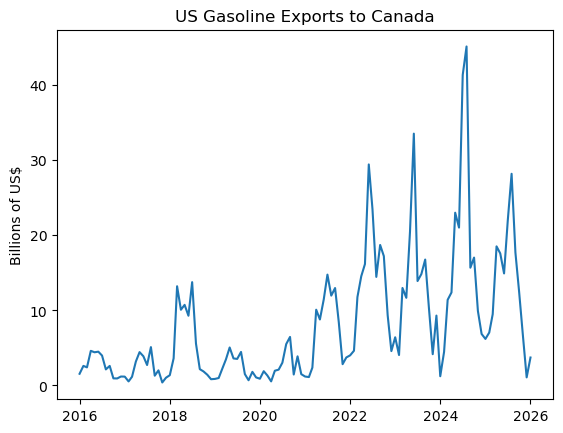

In [33]:
# If/else
if response.ok:
    # If server responds run this code:
    exports = pd.DataFrame(response.json()[1:],columns=response.json()[0])
    print(type(exports["ALL_VAL_MO"][2]))
    
    # Convert time to datetime
    exports['time'] = pd.to_datetime(exports['time'])
    exports["ALL_VAL_MO"] = exports["ALL_VAL_MO"].astype(float)/100000

    # Plot the data over time
    fig, ax = plt.subplots()
    ax.plot(exports["time"], exports["ALL_VAL_MO"])
    ax.set(ylabel="Billions of US$",
           title="US Gasoline Exports to Canada")

    plt.show()
    
else:
    # otherwise display the status code:
    print("Error ",response.status_code)

## Practice - Census API
1. Instead of US Oil Exports to Canada, find US Imports from Russia
2. Start from January 2016 to now
3. Create a line plot of imports over time. Does anything stand out?

<class 'str'>


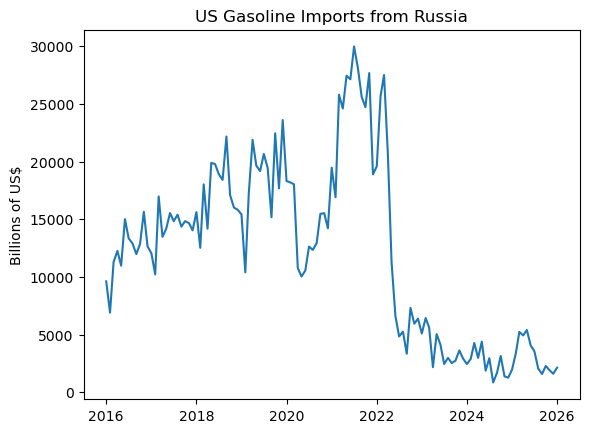

In [42]:
# Results:
# Set query parameters
base_url = 'https://api.census.gov/data/timeseries/intltrade/imports/hs'
variables = 'GEN_VAL_MO,CTY_NAME'
country = '4621'
dates = 'from+2016-01'

# Formula full URL
full_url = (base_url
            + '?get=' + variables 
            + '&CTY_CODE=' + country
            + '&time=' + dates)

# Submit query
response = requests.get(full_url)

# Clean up resulting data frame 
imports = pd.DataFrame(response.json()[1:],columns=response.json()[0])

# Convert time to datetime
imports['time'] = pd.to_datetime(imports['time'])
imports["GEN_VAL_MO"] = imports["GEN_VAL_MO"].astype(float)/100000

# Plot the data over time
fig, ax = plt.subplots()
ax.plot(imports["time"], imports["GEN_VAL_MO"])
ax.set(ylabel="Billions of US$",
       title="US Gasoline Imports from Russia")

plt.show()